In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.names
/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.data


# Cell 1 — Import Libraries

In [17]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Cell 2 — Plot Formatting

In [18]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

sns.set(style="whitegrid")

def set_plot_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'savefig.dpi': 600,
    })

def save_current_plot(name, folder="figures", close=False):
    os.makedirs(folder, exist_ok=True)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')
    fig = plt.gcf()
    path = os.path.join(folder, f"{safe_name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    if close:
        plt.close(fig)
    return path

# Cell 3 — Load Dataset

In [19]:
data_path = "/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.data"

columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(
    data_path,
    header=None,
    names=columns
)

print("Dataset Shape:", df.shape)
print(df.head())

X = df.drop(columns=["id", "diagnosis"])

# 0 = Benign, 1 = Malignant
y = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Features:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())


Dataset Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  

# Cell 4 — Display Dataset

In [20]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Cell 5 — Dataset Information

In [21]:
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

Number of Samples: 569
Number of Features: 30

Missing Values:
0

Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Cell 6 — Class Distribution

Saved: figures/class_distribution.eps


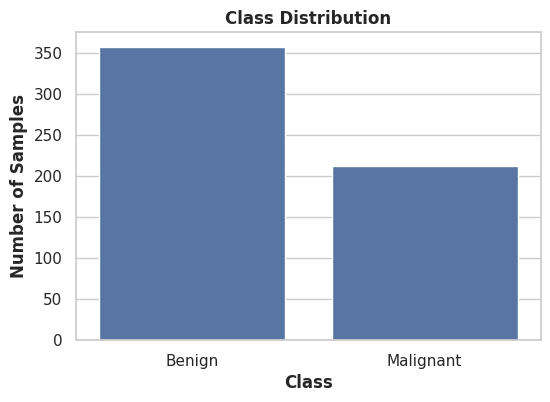

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.xticks([0, 1], ["Benign", "Malignant"])

save_current_plot("class_distribution")
plt.show()


# Cell 7 — Correlation Heatmap

Saved: figures/correlation_heatmap.eps


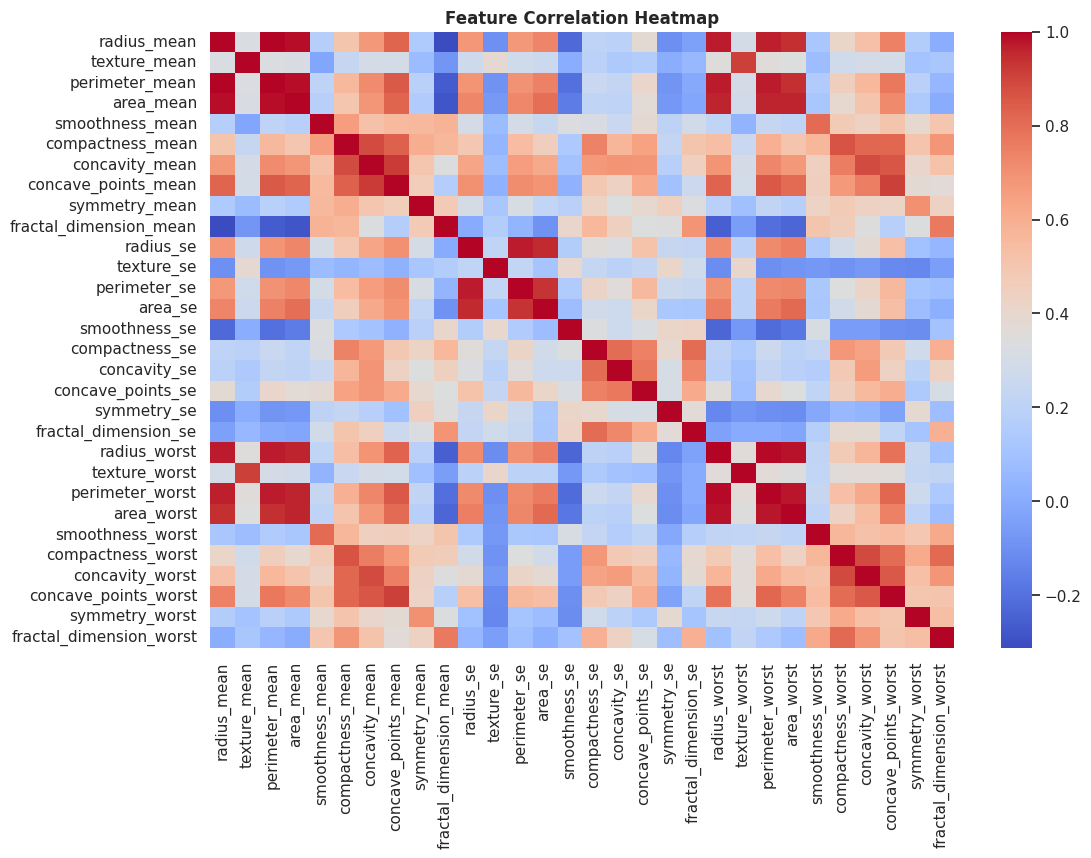

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(X.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

save_current_plot("correlation_heatmap")
plt.show()

# Cell 8 — Split Dataset

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


# Cell 9 — Bagging Model

In [25]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.7, 1.0],
    'max_features': [0.7, 1.0]
}

# Cell 10 — Bagging Hyperparameter Search

In [26]:
bagging_grid = GridSearchCV(
    bagging,
    bagging_params,
    cv=5,
    scoring="accuracy"
)

bagging_grid.fit(X_train, y_train)

print("Best Bagging Parameters:")
print(bagging_grid.best_params_)

print("\nBest CV Accuracy:")
print(bagging_grid.best_score_)


Best Bagging Parameters:
{'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 100}

Best CV Accuracy:
0.9692307692307693


# Cell 11 — Table 1

In [27]:
bagging_results = []

for n in [10, 50, 100]:
    for samples in [0.7, 1.0]:
        model = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=n,
            max_samples=samples,
            max_features=1.0,
            random_state=42
        )

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=5,
            scoring=["accuracy", "f1"]
        )

        bagging_results.append([
            n,
            samples,
            scores["test_accuracy"].mean() * 100,
            scores["test_f1"].mean()
        ])

table1 = pd.DataFrame(
    bagging_results,
    columns=[
        "n estimators",
        "max samples",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score"
    ]
)

table1["Avg CV Accuracy (%)"] = table1["Avg CV Accuracy (%)"].round(2)
table1["Avg CV F1 Score"] = table1["Avg CV F1 Score"].round(4)

table1


,n estimators,max samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.7,94.95,0.9330
1,10,1.0,95.16,0.9362
2,50,0.7,94.73,0.9300
3,50,1.0,95.82,0.9456
4,100,0.7,95.16,0.9365
5,100,1.0,95.82,0.9457


# Cell 12 — Calculate Bagging CV F1 Scores

In [28]:
table1


,n estimators,max samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.7,94.95,0.9330
1,10,1.0,95.16,0.9362
2,50,0.7,94.73,0.9300
3,50,1.0,95.82,0.9456
4,100,0.7,95.16,0.9365
5,100,1.0,95.82,0.9457


# Cell 13 — Best Bagging Model

In [29]:
best_bagging = bagging_grid.best_estimator_

best_bagging.fit(X_train, y_train)

bagging_pred = best_bagging.predict(X_test)
bagging_prob = best_bagging.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    bagging_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# Cell 14 — AdaBoost Model

In [30]:
boosting = AdaBoostClassifier(
    random_state=42
)

boosting_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.5, 1.0]
}

# Cell 15 — Boosting Hyperparameter Search

In [31]:
boosting_grid = GridSearchCV(
    boosting,
    boosting_params,
    cv=5,
    scoring='accuracy'
)

boosting_grid.fit(X_train, y_train)

print("Best Boosting Parameters:")
print(boosting_grid.best_params_)

print("\nBest CV Accuracy:")
print(boosting_grid.best_score_)

Best Boosting Parameters:
{'learning_rate': 1.0, 'n_estimators': 50}

Best CV Accuracy:
0.9626373626373628


# Cell 16 — Table 2

In [32]:
boosting_results = []

for n in [50, 100, 150]:
    for lr in [0.5, 1.0]:

        model = AdaBoostClassifier(
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )

        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=5,
            scoring=['accuracy', 'f1']
        )

        boosting_results.append([
            n,
            lr,
            scores['test_accuracy'].mean() * 100,
            scores['test_f1'].mean()
        ])

table2 = pd.DataFrame(
    boosting_results,
    columns=[
        'n estimators',
        'learning rate',
        'Avg CV Accuracy (%)',
        'Avg CV F1 Score'
    ]
)

table2['Avg CV Accuracy (%)'] = table2['Avg CV Accuracy (%)'].round(2)
table2['Avg CV F1 Score'] = table2['Avg CV F1 Score'].round(4)

table2

,n estimators,learning rate,Avg CV Accuracy (%),Avg CV F1 Score
0,50,0.5,95.82,0.9441
1,50,1.0,96.26,0.9489
2,100,0.5,95.60,0.9406
3,100,1.0,96.04,0.9463
4,150,0.5,96.04,0.9464
5,150,1.0,96.04,0.9463


# Cell 17 — Best Boosting Model

In [33]:
best_boosting = boosting_grid.best_estimator_

best_boosting.fit(X_train, y_train)

boosting_pred = best_boosting.predict(X_test)
boosting_prob = best_boosting.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    boosting_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Cell 18 — Define Base Models

In [34]:
svm = SVC(
    probability=True,
    random_state=42
)

nb = GaussianNB()

dt = DecisionTreeClassifier(
    random_state=42
)

base_models = [
    ('svm', svm),
    ('nb', nb),
    ('dt', dt)
]

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Cell 19 — Stacking Model

In [35]:
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking.fit(X_train, y_train)

stacking_pred = stacking.predict(X_test)
stacking_prob = stacking.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    stacking_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95        72
   Malignant       0.97      0.83      0.90        42

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



# Cell 20 — Table 3

In [36]:
stacking_scores = cross_validate(
    stacking,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'f1']
)

table3 = pd.DataFrame({
    'Base Models': ['SVM, Naive Bayes, Decision Tree'],
    'Meta Learner': ['Logistic Regression'],
    'Avg CV Accuracy (%)': [
        stacking_scores['test_accuracy'].mean() * 100
    ],
    'Avg CV F1 Score': [
        stacking_scores['test_f1'].mean()
    ]
})

table3['Avg CV Accuracy (%)'] = table3['Avg CV Accuracy (%)'].round(2)
table3['Avg CV F1 Score'] = table3['Avg CV F1 Score'].round(4)

table3

,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,"SVM, Naive Bayes, Decision Tree",Logistic Regression,94.29,0.9213


# Cell 21 — Calculate Performance Metrics

In [37]:
models = {
    "Bagging": bagging_pred,
    "Boosting": boosting_pred,
    "Stacked Ensemble": stacking_pred
}

performance = []

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction, pos_label=1)
    recall = recall_score(y_test, prediction, pos_label=1)
    f1 = f1_score(y_test, prediction, pos_label=1)

    performance.append([
        name,
        accuracy * 100,
        precision,
        recall,
        f1
    ])

table4 = pd.DataFrame(
    performance,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

table4["Accuracy (%)"] = table4["Accuracy (%)"].round(2)
table4["Precision"] = table4["Precision"].round(4)
table4["Recall"] = table4["Recall"].round(4)
table4["F1 Score"] = table4["F1 Score"].round(4)

table4


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.49,1.0000,0.9048,0.9500
1,Boosting,98.25,1.0000,0.9524,0.9756
2,Stacked Ensemble,92.98,0.9722,0.8333,0.8974


# Cell 22 — Bagging Confusion Matrix

Saved: figures/bagging_confusion_matrix.eps


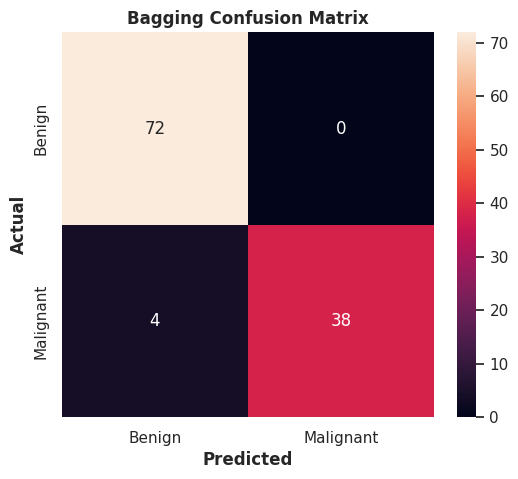

In [38]:
cm = confusion_matrix(y_test, bagging_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion Matrix")

save_current_plot("bagging_confusion_matrix")
plt.show()

# Cell 23 — Boosting Confusion Matrix

Saved: figures/boosting_confusion_matrix.eps


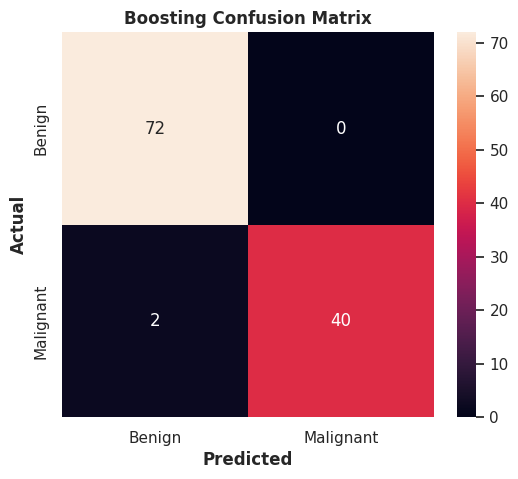

In [39]:
cm = confusion_matrix(y_test, boosting_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Boosting Confusion Matrix")

save_current_plot("boosting_confusion_matrix")
plt.show()

# Cell 24 — Stacking Confusion Matrix

Saved: figures/stacked_ensemble_confusion_matrix.eps


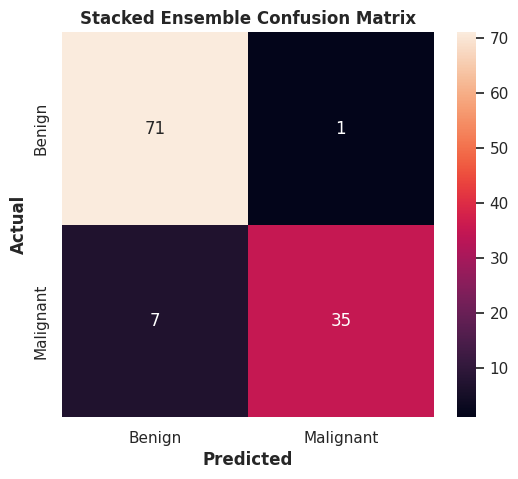

In [40]:
cm = confusion_matrix(y_test, stacking_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacked Ensemble Confusion Matrix")

save_current_plot("stacked_ensemble_confusion_matrix")
plt.show()

# Cell 25 — ROC Curves

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve_comparison.eps


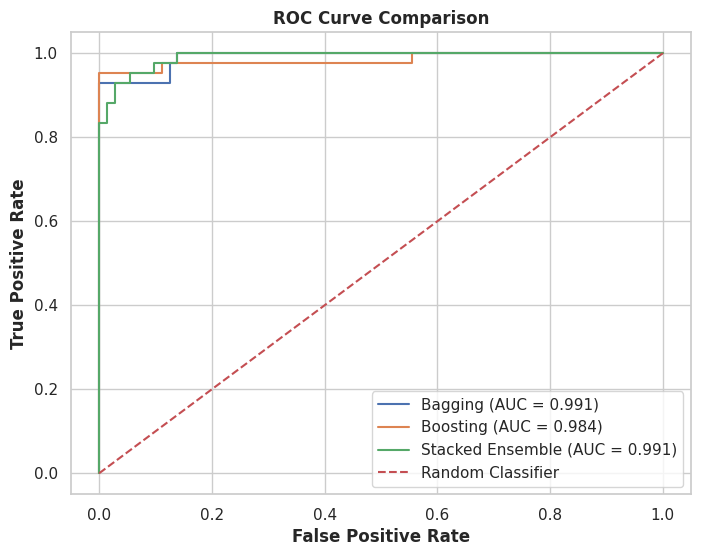

In [41]:
bagging_fpr, bagging_tpr, _ = roc_curve(
    y_test,
    bagging_prob,
    pos_label=1
)

boosting_fpr, boosting_tpr, _ = roc_curve(
    y_test,
    boosting_prob,
    pos_label=1
)

stacking_fpr, stacking_tpr, _ = roc_curve(
    y_test,
    stacking_prob,
    pos_label=1
)

bagging_auc = roc_auc_score(y_test, bagging_prob)
boosting_auc = roc_auc_score(y_test, boosting_prob)
stacking_auc = roc_auc_score(y_test, stacking_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    bagging_fpr,
    bagging_tpr,
    label=f"Bagging (AUC = {bagging_auc:.3f})"
)

plt.plot(
    boosting_fpr,
    boosting_tpr,
    label=f"Boosting (AUC = {boosting_auc:.3f})"
)

plt.plot(
    stacking_fpr,
    stacking_tpr,
    label=f"Stacked Ensemble (AUC = {stacking_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

save_current_plot("roc_curve_comparison")
plt.show()


# Cell 26 — Print AUC

In [42]:
print("Bagging AUC:", round(bagging_auc, 4))
print("Boosting AUC:", round(boosting_auc, 4))
print("Stacked Ensemble AUC:", round(stacking_auc, 4))

Bagging AUC: 0.9907
Boosting AUC: 0.9841
Stacked Ensemble AUC: 0.9911


# Cell 27 — Accuracy Comparison

Saved: figures/ensemble_accuracy_comparison.eps


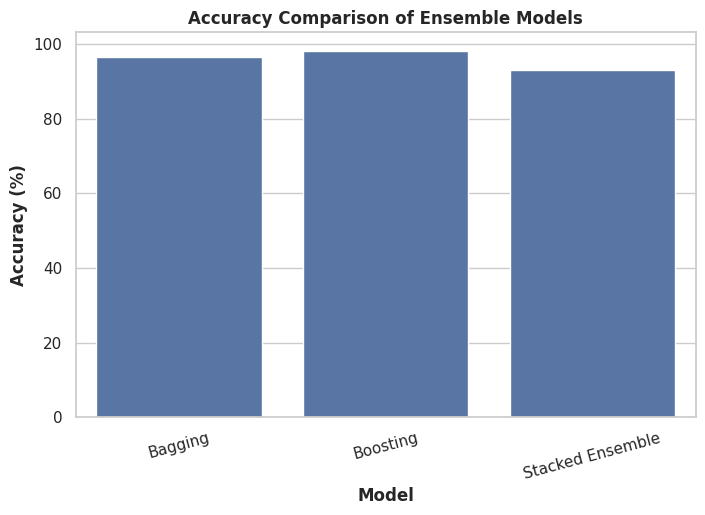

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=table4,
    x='Model',
    y='Accuracy (%)'
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Ensemble Models")

plt.xticks(rotation=15)

save_current_plot("ensemble_accuracy_comparison")
plt.show()

# Cell 28 — F1 Comparison

Saved: figures/ensemble_f1_comparison.eps


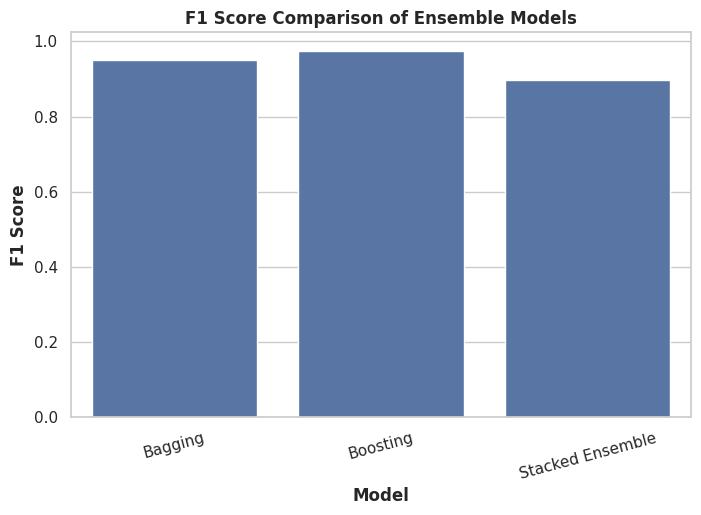

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=table4,
    x='Model',
    y='F1 Score'
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Ensemble Models")

plt.xticks(rotation=15)

save_current_plot("ensemble_f1_comparison")
plt.show()

# Cell 29 — Final Tables

In [45]:
print("TABLE 1: BAGGING HYPERPARAMETER EVALUATION")
display(table1)

print("\nTABLE 2: BOOSTING HYPERPARAMETER EVALUATION")
display(table2)

print("\nTABLE 3: STACKED ENSEMBLE EVALUATION")
display(table3)

print("\nTABLE 4: PERFORMANCE COMPARISON")
display(table4)

TABLE 1: BAGGING HYPERPARAMETER EVALUATION


,n estimators,max samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.7,94.95,0.9330
1,10,1.0,95.16,0.9362
2,50,0.7,94.73,0.9300
3,50,1.0,95.82,0.9456
4,100,0.7,95.16,0.9365
5,100,1.0,95.82,0.9457



TABLE 2: BOOSTING HYPERPARAMETER EVALUATION


,n estimators,learning rate,Avg CV Accuracy (%),Avg CV F1 Score
0,50,0.5,95.82,0.9441
1,50,1.0,96.26,0.9489
2,100,0.5,95.60,0.9406
3,100,1.0,96.04,0.9463
4,150,0.5,96.04,0.9464
5,150,1.0,96.04,0.9463



TABLE 3: STACKED ENSEMBLE EVALUATION


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,"SVM, Naive Bayes, Decision Tree",Logistic Regression,94.29,0.9213



TABLE 4: PERFORMANCE COMPARISON


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.49,1.0000,0.9048,0.9500
1,Boosting,98.25,1.0000,0.9524,0.9756
2,Stacked Ensemble,92.98,0.9722,0.8333,0.8974


# Cell 30 — Best Model

In [46]:
best_model = table4.loc[
    table4['Accuracy (%)'].idxmax(),
    'Model'
]

best_accuracy = table4['Accuracy (%)'].max()

print("Best Performing Model:", best_model)
print("Accuracy:", best_accuracy, "%")

Best Performing Model: Boosting
Accuracy: 98.25 %
